# Exploración de los datos procesados por trabajador
Este notebook analiza los archivos `combined_features_1min.csv` generados para cada trabajador.

Incluye tamaño de los archivos, número de ventanas, columnas, rango temporal, actividades, ejemplos y datos faltantes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidate_roots = [Path.cwd(), Path.cwd().parent]
root_dir = next(
    (
        root
        for root in candidate_roots
        if any(root.glob("Worker * - */PROCESSED/combined_features_1min.csv"))
    ),
    None,
)
if root_dir is None:
    raise FileNotFoundError(
        "No se encontraron las carpetas Worker */PROCESSED desde la ubicacion actual."
    )

worker_files = {
    worker_dir.name: worker_dir / "PROCESSED" / "combined_features_1min.csv"
    for worker_dir in sorted(root_dir.glob("Worker * - *"))
    if (worker_dir / "PROCESSED" / "combined_features_1min.csv").exists()
}

if not worker_files:
    raise FileNotFoundError("No se encontraron archivos combined_features_1min.csv.")

data = {worker: pd.read_csv(path) for worker, path in worker_files.items()}
print(f"Carpeta de datos: {root_dir}")
print(f"Trabajadores encontrados: {list(data)}")
print(f"Trabajadores ausentes: {[worker_dir.name for worker_dir in sorted(root_dir.glob('Worker * - *')) if worker_dir.name not in data]}")

Carpeta de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\2026-06-29 ECG
Trabajadores encontrados: ['Worker 1 - 001', 'Worker 2 - 007', 'Worker 3 - 005', 'Worker 4 - 004', 'Worker 5 - 011']
Trabajadores ausentes: []


## Localizar los archivos
El notebook analiza los archivos procesados del experimento del 29/06/2026, organizados en las carpetas `Worker 1 - 001` hasta `Worker 5 - 011`.

In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
root_dir = next(
    (
        root
        for root in candidate_roots
        if any(root.glob("Worker * - */PROCESSED/combined_features_1min.csv"))
    ),
    None,
)
if root_dir is None:
    raise FileNotFoundError(
        "No se encontraron las carpetas Worker */PROCESSED desde la ubicacion actual."
    )

worker_files = {
    worker_dir.name: worker_dir / "PROCESSED" / "combined_features_1min.csv"
    for worker_dir in sorted(root_dir.glob("Worker * - *"))
    if (worker_dir / "PROCESSED" / "combined_features_1min.csv").exists()
}

if not worker_files:
    raise FileNotFoundError("No se encontraron archivos combined_features_1min.csv.")

data = {worker: pd.read_csv(path) for worker, path in worker_files.items()}
print(f"Carpeta de datos: {root_dir}")
print(f"Trabajadores encontrados: {list(data)}")
print(f"Trabajadores ausentes: {[worker_dir.name for worker_dir in sorted(root_dir.glob('Worker * - *')) if worker_dir.name not in data]}")

Carpeta de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\2026-06-29 ECG
Trabajadores encontrados: ['Worker 1 - 001', 'Worker 2 - 007', 'Worker 3 - 005', 'Worker 4 - 004', 'Worker 5 - 011']
Trabajadores ausentes: []


## Resumen general
Cada fila representa una ventana temporal de un minuto. `DateTime` contiene únicamente la hora de inicio de la ventana.

In [3]:
summary_rows = []
for worker, df in data.items():
    file_path = worker_files[worker]
    summary_rows.append({
        'Trabajador': worker,
        'Archivo': file_path.name,
        'Tamaño (KB)': round(file_path.stat().st_size / 1024, 2),
        'Filas / ventanas': len(df),
        'Columnas': len(df.columns),
        'Primera hora': df['DateTime'].iloc[0] if len(df) else '',
        'Última hora': df['DateTime'].iloc[-1] if len(df) else '',
        'HR_valid = 1': int((df['HR_valid'] == 1).sum()) if 'HR_valid' in df else 0,
        'HR_valid = 0': int((df['HR_valid'] == 0).sum()) if 'HR_valid' in df else 0,
    })

summary = pd.DataFrame(summary_rows)
summary

,Trabajador,Archivo,Tamaño (KB),Filas / ventanas,Columnas,Primera hora,Última hora,HR_valid = 1,HR_valid = 0
0,Worker 1 - 001,combined_features_1min.csv,13.90,74,16,08:53:19,13:47:40,34,40
1,Worker 2 - 007,combined_features_1min.csv,8.19,35,16,08:47:07,10:19:58,31,4
2,Worker 3 - 005,combined_features_1min.csv,16.10,67,16,08:44:38,11:21:15,67,0
3,Worker 4 - 004,combined_features_1min.csv,19.79,133,16,00:00:00,11:52:15,12,121
4,Worker 5 - 011,combined_features_1min.csv,2.98,16,16,08:49:33,09:59:24,6,10


## Estructura y ejemplos
Se muestran las columnas disponibles y las primeras filas de cada trabajador.

In [4]:
for worker, df in data.items():
    print(f'\n--- {worker} ---')
    print('Columnas:', list(df.columns))
    display(df.head(3))


--- Worker 1 - 001 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1782719599280738307,08:53:19,No especificada,0,-0.136022,0.328046,5.458,0.126103,0.232089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1782719659281516884,08:54:19,No especificada,0,-0.109862,0.274990,2.467,0.087680,0.310564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1782719719283058407,08:55:19,No especificada,0,-0.111805,0.251590,2.209,0.075790,0.220931,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Worker 2 - 007 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1782719227718556632,08:47:07,No especificada,1,-0.176152,0.332148,3.291,0.141338,0.100264,22.0,117.002571,159.343512,16.129032,79.766922,152.671756,39.370079
1,1782719287722372815,08:48:07,No especificada,1,-0.182989,0.242503,2.149,0.092285,0.126339,22.0,57.505606,28.877791,6.097561,82.288207,96.463023,68.649886
2,1782719347728714142,08:49:07,No especificada,1,-0.155058,0.240655,2.019,0.081951,0.121016,20.0,55.474402,35.780021,12.345679,81.640781,94.936709,69.044879



--- Worker 3 - 005 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1782719078794347720,08:44:38,No especificada,1,-0.377436,0.274944,2.578,0.218037,0.239230,43,0.000000,0.000000,0.000000,82.304527,82.304527,82.304527
1,1782723020207190415,09:50:20,No especificada,1,-0.049876,0.289791,2.380,0.086455,0.200165,21,106.905799,68.306894,18.750000,86.793419,110.497238,58.027079
2,1782723080207646118,09:51:20,No especificada,1,-0.050520,0.286737,2.350,0.084760,0.207106,30,78.184550,41.176378,18.823529,86.050196,99.667774,66.592675



--- Worker 4 - 004 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1,00:00:00,No especificada,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1782718892364884940,08:41:32,No especificada,1,-0.389749,0.180467,2.130,0.184468,0.187614,12.0,80.777158,41.101118,22.641509,54.313206,60.851927,47.355959
2,1782718952372139711,08:42:32,No especificada,1,-0.323297,0.173249,2.213,0.134532,0.185532,12.0,144.089582,99.482507,30.769231,52.574149,108.695652,44.378698



--- Worker 5 - 011 ---
Columnas: ['UNIX Timestamp', 'DateTime', 'Actividad', 'HR_valid', 'ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1782719373470163572,08:49:33,No especificada,1,-0.133853,0.449108,5.245,0.219588,0.340871,34.0,17.016332,16.419501,0.0,92.927207,94.637224,87.97654
1,1782719433472512431,08:50:33,No especificada,0,-0.086319,0.859429,17.454,0.745975,0.180188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1782719493479439577,08:51:33,No especificada,0,-0.081290,0.292083,3.353,0.091910,0.414866,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Actividades registradas
La actividad se asigna según los horarios descritos en `Readme.txt`. La tabla muestra cuántas ventanas tiene cada categoría.

In [5]:
activity_counts = []
for worker, df in data.items():
    counts = df['Actividad'].value_counts(dropna=False)
    for activity, count in counts.items():
        activity_counts.append({'Trabajador': worker, 'Actividad': activity, 'Ventanas': int(count)})

activity_table = pd.DataFrame(activity_counts)
activity_table.pivot(index='Actividad', columns='Trabajador', values='Ventanas').fillna(0).astype(int)

Trabajador,Worker 1 - 001,Worker 2 - 007,Worker 3 - 005,Worker 4 - 004,Worker 5 - 011
Actividad,,,,,
No especificada,74,35,67,133,16


## Datos faltantes
Una celda vacía indica que la variable no pudo calcularse en esa ventana. No debe interpretarse como un valor numérico igual a cero.

`HR_valid = 1` significa que las variables agregadas derivadas de HR/RR (`SDNN`, `RMSSD`, `pNN50`, `HR_mean`, `HR_max` y `HR_min`) pudieron calcularse y son válidas. `HR_valid = 0` significa que falta información suficiente para calcularlas.

In [6]:
missing_rows = []
for worker, df in data.items():
    missing = df.isna() | df.astype('object').eq('')
    for column in df.columns:
        missing_rows.append({
            'Trabajador': worker,
            'Columna': column,
            'Celdas faltantes': int(missing[column].sum()),
            'Filas afectadas': int(missing[column].sum()),
            'Porcentaje de filas': round(100 * missing[column].sum() / len(df), 2) if len(df) else 0,
        })

missing_table = pd.DataFrame(missing_rows)
missing_table[missing_table['Celdas faltantes'] > 0].sort_values(['Trabajador', 'Celdas faltantes'], ascending=[True, False])

,Trabajador,Columna,Celdas faltantes,Filas afectadas,Porcentaje de filas
9,Worker 1 - 001,ECG_missing_peaks,40,40,54.05
10,Worker 1 - 001,SDNN,40,40,54.05
11,Worker 1 - 001,RMSSD,40,40,54.05
12,Worker 1 - 001,pNN50,40,40,54.05
13,Worker 1 - 001,HR_mean,40,40,54.05
14,Worker 1 - 001,HR_max,40,40,54.05
15,Worker 1 - 001,HR_min,40,40,54.05
25,Worker 2 - 007,ECG_missing_peaks,4,4,11.43
26,Worker 2 - 007,SDNN,4,4,11.43
27,Worker 2 - 007,RMSSD,4,4,11.43


In [7]:
hrv_columns = ['SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
hrv_rows = []
for worker, df in data.items():
    available_hrv_columns = [column for column in hrv_columns if column in df.columns]
    rows_with_missing_hrv = df[available_hrv_columns].isna().any(axis=1) | df[available_hrv_columns].astype('object').eq('').any(axis=1)
    hrv_rows.append({
        'Trabajador': worker,
        'Ventanas totales': len(df),
        'Ventanas HR_valid = 1': int((df['HR_valid'] == 1).sum()),
        'Ventanas HR_valid = 0': int((df['HR_valid'] == 0).sum()),
        'Ventanas con alguna variable HRV faltante': int(rows_with_missing_hrv.sum()),
        'Porcentaje con HRV faltante': round(100 * rows_with_missing_hrv.mean(), 2) if len(df) else 0,
    })

hrv_summary = pd.DataFrame(hrv_rows)
hrv_summary

,Trabajador,Ventanas totales,Ventanas HR_valid = 1,Ventanas HR_valid = 0,Ventanas con alguna variable HRV faltante,Porcentaje con HRV faltante
0,Worker 1 - 001,74,34,40,40,54.05
1,Worker 2 - 007,35,31,4,4,11.43
2,Worker 3 - 005,67,67,0,0,0.00
3,Worker 4 - 004,133,12,121,121,90.98
4,Worker 5 - 011,16,6,10,10,62.50


## Ventanas faltantes por actividad
Se agrupan las ventanas por trabajador y actividad para comprobar en qué actividades se concentra la falta de información de HR/RR.

In [8]:
activity_missing_rows = []
for worker, df in data.items():
    activity_group = df.groupby('Actividad', dropna=False)
    for activity, group in activity_group:
        total_windows = len(group)
        valid_windows = int((group['HR_valid'] == 1).sum())
        invalid_windows = int((group['HR_valid'] == 0).sum())
        activity_missing_rows.append({
            'Trabajador': worker,
            'Actividad': activity,
            'Ventanas totales': total_windows,
            'HR_valid = 1': valid_windows,
            'HR_valid = 0': invalid_windows,
            'Porcentaje faltante': round(100 * invalid_windows / total_windows, 2) if total_windows else 0,
        })

activity_missing_table = pd.DataFrame(activity_missing_rows)
activity_missing_table.sort_values(['Trabajador', 'Actividad'])

,Trabajador,Actividad,Ventanas totales,HR_valid = 1,HR_valid = 0,Porcentaje faltante
0,Worker 1 - 001,No especificada,74,34,40,54.05
1,Worker 2 - 007,No especificada,35,31,4,11.43
2,Worker 3 - 005,No especificada,67,67,0,0.00
3,Worker 4 - 004,No especificada,133,12,121,90.98
4,Worker 5 - 011,No especificada,16,6,10,62.50


## Ventanas faltantes por actividad
Se agrupan las ventanas por trabajador y actividad para comprobar en qué actividades se concentra la falta de información de HR/RR.

In [9]:
worker_to_inspect = next(iter(data))
df_inspect = data[worker_to_inspect]
columns_to_check = ['HR_valid'] + [column for column in hrv_columns if column in df_inspect.columns]
missing_mask = df_inspect[columns_to_check].isna() | df_inspect[columns_to_check].astype('object').eq('')
rows_with_missing = df_inspect.loc[missing_mask.any(axis=1)]
print(f'Trabajador inspeccionado: {worker_to_inspect}')
print(f'Filas con algun dato faltante en las columnas seleccionadas: {len(rows_with_missing)}')
display(rows_with_missing.head(20))

Trabajador inspeccionado: Worker 1 - 001
Filas con algun dato faltante en las columnas seleccionadas: 40


,UNIX Timestamp,DateTime,Actividad,HR_valid,ECG_mean,ECG_std,ECG_range,ECG_energy,ECG_samp_ent,ECG_missing_peaks,SDNN,RMSSD,pNN50,HR_mean,HR_max,HR_min
0,1782719599280738307,08:53:19,No especificada,0,-0.136022,0.328046,5.458,0.126103,0.232089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1782719659281516884,08:54:19,No especificada,0,-0.109862,0.274990,2.467,0.087680,0.310564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1782719719283058407,08:55:19,No especificada,0,-0.111805,0.251590,2.209,0.075790,0.220931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1782720019305732501,09:00:19,No especificada,0,-0.084438,0.245541,2.437,0.067412,0.205650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1782720079310499352,09:01:19,No especificada,0,-0.061648,0.277517,2.925,0.080806,0.368532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1782720139316184047,09:02:19,No especificada,0,-0.080457,0.257885,2.625,0.072970,0.308279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,1782720199322321236,09:03:19,No especificada,0,-0.069539,0.258197,2.717,0.071493,0.241497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,1782720259328831601,09:04:19,No especificada,0,-0.072058,0.276117,3.549,0.081423,0.197978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,1782720319336332249,09:05:19,No especificada,0,-0.067302,0.261827,2.952,0.073074,0.195012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,1782720379337072072,09:06:19,No especificada,0,-0.071953,0.254096,2.832,0.069734,0.270479,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribución de HR_valid
Este gráfico permite comparar rápidamente qué trabajadores tienen ventanas con información suficiente de HR/RR.

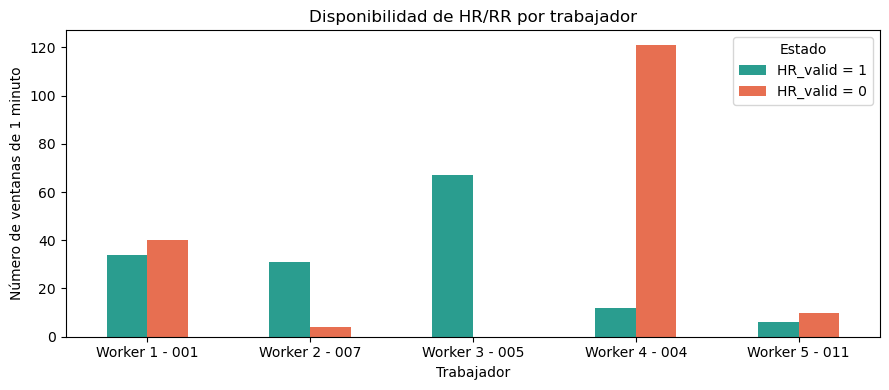

In [10]:
hr_valid_plot = summary.set_index('Trabajador')[['HR_valid = 1', 'HR_valid = 0']]
ax = hr_valid_plot.plot(kind='bar', figsize=(9, 4), color=['#2a9d8f', '#e76f51'])
ax.set_xlabel('Trabajador')
ax.set_ylabel('Número de ventanas de 1 minuto')
ax.set_title('Disponibilidad de HR/RR por trabajador')
ax.legend(title='Estado')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()